# Classification Pipeline

Target: `upgrade_first`


In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import shap
import os
import joblib
from pathlib import Path
import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from dotenv import load_dotenv
from openai import OpenAI


shap.initjs()

In [2]:
candidate_paths = [
    Path("../preprocessing/data/cleaned_laptop_data.csv")
]

cleaned_path = None
for p in candidate_paths:
    if p.exists():
        cleaned_path = p
        break

if cleaned_path is None:
    raise FileNotFoundError("Could not find cleaned_laptop_data.csv")

print("Using cleaned file:", cleaned_path)
data = pd.read_csv(cleaned_path)
print("Shape:", data.shape)
data.head()

Using cleaned file: ..\preprocessing\data\cleaned_laptop_data.csv
Shape: (19545, 53)


,type_name,user_profile,budget_class,upgrade_first,gain_class,price,recommended_upgrade_cost_est,inches,weight_kg,opsys,...,gpu_urgency_score,performance_score,ram_gap_ratio,storage_gap_ratio,gpu_gap_ratio,upgrade_pressure,total_urgency,price_per_performance,storage_capacity_score,storage_speed_score
0,Ultrabook,student,low,Storage,Low,71378.68,43.72,13.3,1.37,macOS,...,0.0,12.150286,0.0,0.498054,0.0,0.124514,0.113667,5427.918441,128,128.0
1,Ultrabook,student,medium,Storage,Low,71378.68,43.72,13.3,1.37,macOS,...,0.0,12.150286,0.0,0.498054,0.0,0.124514,0.113667,5427.918441,128,128.0
2,Ultrabook,student,high,Storage,Low,71378.68,43.72,13.3,1.37,macOS,...,0.0,12.150286,0.0,0.498054,0.0,0.124514,0.113667,5427.918441,128,128.0
3,Ultrabook,office,low,Storage,Low,71378.68,43.72,13.3,1.37,macOS,...,0.0,12.150286,0.0,0.498054,0.0,0.124514,0.113667,5427.918441,128,128.0
4,Ultrabook,office,medium,Storage,Low,71378.68,43.72,13.3,1.37,macOS,...,0.0,12.150286,0.0,0.498054,0.0,0.124514,0.113667,5427.918441,128,128.0


In [3]:
# Classification feature set
classification_numeric_features = [
    "ram_gb",
    "total_storage_gb",
    "cpu_score",
    "gpu_score",
    "ram_gap_ratio",
    "storage_gap_ratio",
    "gpu_gap_ratio",
    "upgrade_pressure",
    "total_urgency",
    "performance_score"
]

classification_categorical_features = [
    "type_name",
    "user_profile",
    "budget_class"
]

classification_binary_features = [
    "has_ssd",
    "has_hdd",
    "is_integrated_gpu"
]

classification_features = (
    classification_numeric_features +
    classification_categorical_features +
    classification_binary_features
)

X_clf = data[classification_features].copy()
y_clf = data["upgrade_first"].copy()

print("Feature matrix shape:", X_clf.shape)
print("Target shape:", y_clf.shape)
display(y_clf.value_counts())

Feature matrix shape: (19545, 16)
Target shape: (19545,)


upgrade_first
RAM                  8190
No Upgrade Needed    5659
Storage              3524
GPU                  2172
Name: count, dtype: int64

In [4]:
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

print("Train shape:", X_clf_train.shape)
print("Test shape :", X_clf_test.shape)

Train shape: (15636, 16)
Test shape : (3909, 16)


In [5]:
clf_preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), classification_numeric_features),

    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), classification_categorical_features),

    ("bin", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent"))
    ]), classification_binary_features)
])

X_clf_train_p = clf_preprocessor.fit_transform(X_clf_train)
X_clf_test_p = clf_preprocessor.transform(X_clf_test)

print("Processed train shape:", X_clf_train_p.shape)
print("Processed test shape :", X_clf_test_p.shape)

Processed train shape: (15636, 27)
Processed test shape : (3909, 27)


In [6]:
# Train two models required by the assignment
clf_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

clf_lr = LogisticRegression(
    max_iter=2000
)

clf_rf.fit(X_clf_train_p, y_clf_train)
clf_lr.fit(X_clf_train_p, y_clf_train)
print("Both classification models trained.")

Both classification models trained.


In [7]:
def evaluate_classifier(model, X_test, y_test, name):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    print(f"=== {name} ===")
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1-score :", round(f1, 4))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    return {
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1
    }

rf_results = evaluate_classifier(clf_rf, X_clf_test_p, y_clf_test, "Random Forest Classifier")
lr_results = evaluate_classifier(clf_lr, X_clf_test_p, y_clf_test, "Logistic Regression")

=== Random Forest Classifier ===
Accuracy : 0.9985
Precision: 0.9985
Recall   : 0.9985
F1-score : 0.9985

Classification Report:
                   precision    recall  f1-score   support

              GPU       1.00      0.99      0.99       434
No Upgrade Needed       1.00      1.00      1.00      1132
              RAM       1.00      1.00      1.00      1638
          Storage       1.00      1.00      1.00       705

         accuracy                           1.00      3909
        macro avg       1.00      1.00      1.00      3909
     weighted avg       1.00      1.00      1.00      3909

Confusion Matrix:
[[ 431    1    2    0]
 [   1 1131    0    0]
 [   0    0 1638    0]
 [   1    0    1  703]]
=== Logistic Regression ===
Accuracy : 0.9936
Precision: 0.9936
Recall   : 0.9936
F1-score : 0.9936

Classification Report:
                   precision    recall  f1-score   support

              GPU       0.97      0.99      0.98       434
No Upgrade Needed       1.00      1.00    

In [8]:
results_df = pd.DataFrame([rf_results, lr_results]).sort_values(by="F1", ascending=False)
display(results_df)

best_classifier_name = results_df.iloc[0]["Model"]
best_classifier = clf_rf if best_classifier_name == "Random Forest Classifier" else clf_lr

print("Selected final classification model:", best_classifier_name)

,Model,Accuracy,Precision,Recall,F1
0,Random Forest Classifier,0.998465,0.998465,0.998465,0.998464
1,Logistic Regression,0.993605,0.993648,0.993605,0.993614


Selected final classification model: Random Forest Classifier


In [9]:
# Optional: processed feature names for later SHAP/LIME
ohe = clf_preprocessor.named_transformers_["cat"].named_steps["onehot"]
clf_processed_feature_names = (
    classification_numeric_features +
    list(ohe.get_feature_names_out(classification_categorical_features)) +
    classification_binary_features
)

print("Processed feature count:", len(clf_processed_feature_names))
print(clf_processed_feature_names[:20])

Processed feature count: 27
['ram_gb', 'total_storage_gb', 'cpu_score', 'gpu_score', 'ram_gap_ratio', 'storage_gap_ratio', 'gpu_gap_ratio', 'upgrade_pressure', 'total_urgency', 'performance_score', 'type_name_2 in 1 Convertible', 'type_name_Gaming', 'type_name_Netbook', 'type_name_Notebook', 'type_name_Ultrabook', 'type_name_Workstation', 'user_profile_designer', 'user_profile_gamer', 'user_profile_office', 'user_profile_programmer']


In [10]:
# Save artifacts
artifact_dir = Path("artifacts")
artifact_dir.mkdir(exist_ok=True)

joblib.dump(clf_preprocessor, artifact_dir / "clf_preprocessor.pkl")
joblib.dump(best_classifier, artifact_dir / "best_classifier_model.pkl")
joblib.dump(classification_features, artifact_dir / "classification_features.pkl")
joblib.dump(clf_processed_feature_names, artifact_dir / "clf_processed_feature_names.pkl")

print("Classification artifacts saved in:", artifact_dir.resolve())

Classification artifacts saved in: C:\Users\ahmad\Desktop\uni\3rd year\2nd sem\applied\laptop_decision_portal\notebooks\artifacts


In [11]:
artifact_dir = Path("../notebooks/artifacts")

model_for_shap = joblib.load(artifact_dir / "best_classifier_model.pkl")
feature_names = joblib.load(artifact_dir / "clf_processed_feature_names.pkl")

print(type(model_for_shap))
print("Number of processed features:", len(feature_names))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
Number of processed features: 27


In [12]:
X_sample = X_clf_test_p

if hasattr(X_sample, "toarray"):
    X_sample = X_sample.toarray()

print(X_sample.shape)
print(len(feature_names))

(3909, 27)
27


In [13]:
explainer = shap.TreeExplainer(model_for_shap)
shap_values = explainer.shap_values(X_sample) 

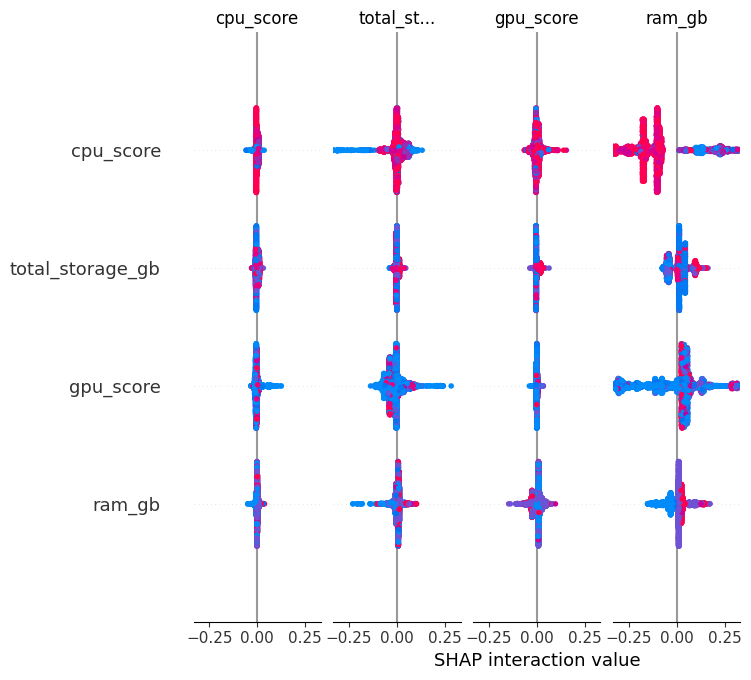

In [14]:
shap.summary_plot(shap_values, X_sample, feature_names=feature_names)

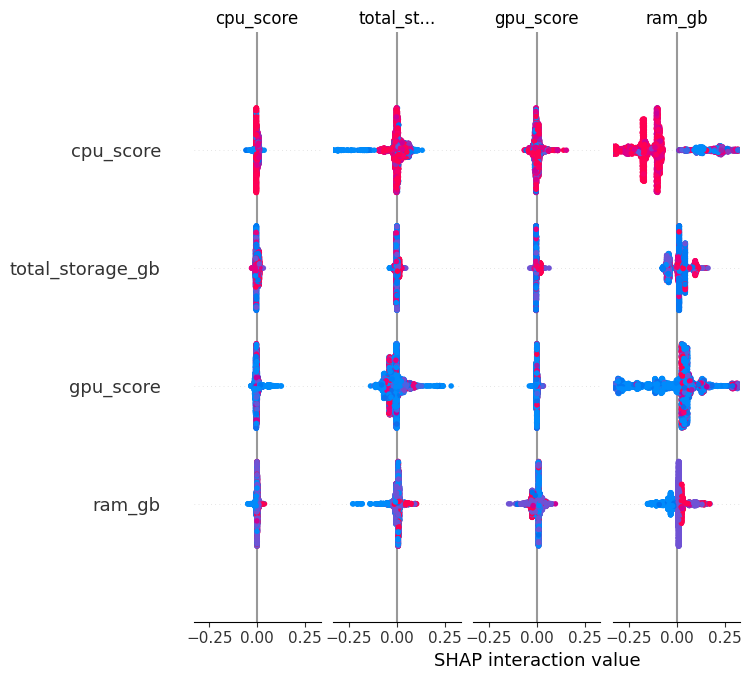

In [15]:
# Global SHAP summary
if isinstance(shap_values, list):
    for class_idx, class_name in enumerate(model_for_shap.classes_):
        print(f"SHAP summary for class: {class_name}")
        shap.summary_plot(
            shap_values[class_idx],
            X_sample,
            feature_names=feature_names
        )
else:
    shap.summary_plot(
        shap_values,
        X_sample,
        feature_names=feature_names
    )

In [16]:
i = 0

print("True label:", y_clf_test.iloc[i])
print("Predicted label:", model_for_shap.predict(X_clf_test_p[i:i+1])[0])

True label: Storage
Predicted label: Storage


In [17]:
if isinstance(shap_values, list):
    pred_class = model_for_shap.predict(X_clf_test_p[i:i+1])[0]
    class_idx = list(model_for_shap.classes_).index(pred_class)

    shap.plots._waterfall.waterfall_legacy(
        explainer.expected_value[class_idx],
        shap_values[class_idx][i],
        feature_names=feature_names
    )

In [18]:
from lime.lime_tabular import LimeTabularExplainer
X_train_lime = X_clf_train_p.toarray() if hasattr(X_clf_train_p, "toarray") else X_clf_train_p
X_test_lime = X_clf_test_p.toarray() if hasattr(X_clf_test_p, "toarray") else X_clf_test_p

lime_explainer = LimeTabularExplainer(
    training_data=X_train_lime,
    feature_names=feature_names,
    class_names=[str(c) for c in model_for_shap.classes_],
    mode="classification"
)

In [19]:
i = 0

lime_exp = lime_explainer.explain_instance(
    data_row=X_test_lime[i],
    predict_fn=model_for_shap.predict_proba,
    num_features=10
)

lime_exp.show_in_notebook(show_table=True) 

In [20]:
print("True label:", y_clf_test.iloc[i])
print("Predicted label:", model_for_shap.predict(X_clf_test_p[i:i+1])[0])

print("\nTop LIME contributions:")
for item in lime_exp.as_list():
    print(item) 

True label: Storage
Predicted label: Storage

Top LIME contributions:
('ram_gap_ratio <= -1.22', 0.08710253303310991)
('has_ssd <= 0.00', -0.07506454906414665)
('-1.14 < total_urgency <= 0.02', -0.05329465239664661)
('upgrade_pressure <= -1.15', -0.03751770732262782)
('storage_gap_ratio <= -0.71', 0.034789740947320485)
('budget_class_low <= 0.00', -0.016425329003143047)
('gpu_gap_ratio <= -0.84', 0.015313540429997387)
('type_name_Gaming <= 0.00', -0.013298560453405784)
('-0.25 < total_storage_gb <= 0.84', 0.01240334107032521)
('user_profile_gamer <= 0.00', 0.009547596861452746)


In [21]:
load_dotenv()

client = OpenAI(
    api_key=os.getenv("GROQ_API"),
    base_url="https://api.groq.com/openai/v1"
)



In [22]:
# Pick ONE example only (important for cost)
i = 0

# Prediction
pred_label = model_for_shap.predict(X_clf_test_p[i:i+1])[0]
true_label = y_clf_test.iloc[i]

# SHAP (top 5 features)
pred_class_idx = list(model_for_shap.classes_).index(pred_label)
local_shap = shap_values[pred_class_idx][i]

top_shap_idx = np.argsort(np.abs(local_shap))[::-1][:5]

top_shap_features = [
    f"{feature_names[idx]}: {round(float(local_shap[idx]), 3)}"
    for idx in top_shap_idx
]

# LIME
lime_points = [
    f"{name}: {round(float(value), 3)}"
    for name, value in lime_exp.as_list()
]

# SIMPLE PROMPT (optimized)
classification_prompt = f"""
Explain this AI prediction simply.

Predicted label: {pred_label}

Top reasons:
{top_shap_features}

Also:
{lime_points}

Explain in 3-4 simple lines with no technical terms.
"""

# API CALL (cheap version)
response = client.chat.completions.create(
    model="llama-3.1-8b-instant",
    messages=[
        {"role": "system", "content": "Explain clearly using only given reasons."},
        {"role": "user", "content": classification_prompt}
    ],
    temperature=0.1,
    max_tokens=120
)

classification_llm_explanation = response.choices[0].message.content

print("\n=== CLASSIFICATION EXPLANATION ===")
print(classification_llm_explanation) 


=== CLASSIFICATION EXPLANATION ===
The AI predicted that the device needs more storage. This is because:

- The device's current storage is relatively small.
- The device does not have a solid-state drive (SSD), which is faster.
- The user might not have a lot of money to upgrade.
- The device is not used for gaming, which often requires more storage.
